# Phase Vorticity

## Background

1. Basic Animation: Sine Wave Propagation
This example demonstrates a simple animated plot of a propagating sine wave, suitable for illustrating wave dynamics in projects related to signal processing or physics.

<IPython.core.display.Javascript object>


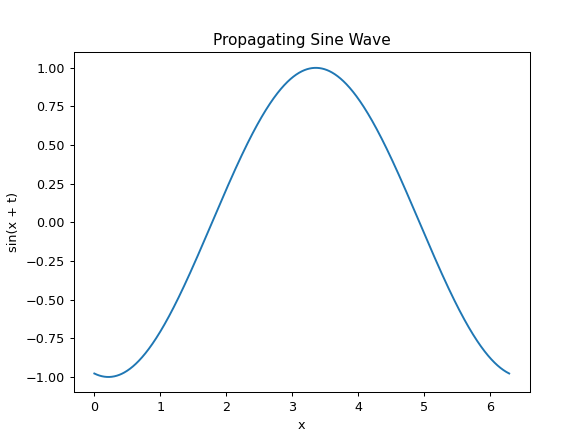

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib notebook  
# Use this for interactive animations in Jupyter

# Set up the figure and axis
fig, ax = plt.subplots()
x = np.linspace(0, 2*np.pi, 1000)
line, = ax.plot(x, np.sin(x))

# Animation function
def animate(frame):
    line.set_ydata(np.sin(x + frame / 10.0))  # Update y-data for each frame
    return line,

# Create the animation
ani = FuncAnimation(fig, animate, frames=200, interval=20, blit=True)

plt.title('Propagating Sine Wave')
plt.xlabel('x')
plt.ylabel('sin(x + t)')
plt.show()

2. Physics Simulation: Simple Pendulum Motion
For projects involving mechanics or dynamical systems, this simulates the motion of a simple pendulum using numerical integration (via SciPy's solve_ivp) and animates the results.

<IPython.core.display.Javascript object>


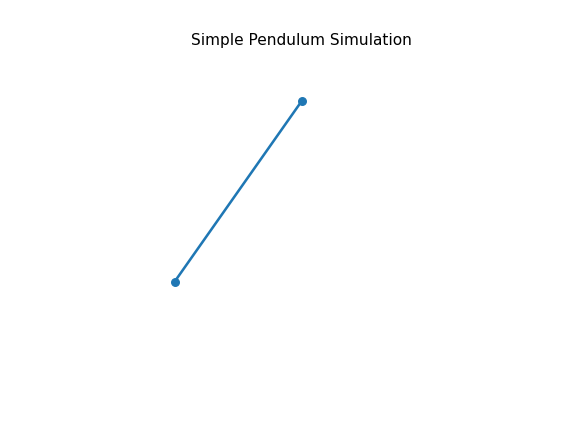

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib notebook

# Pendulum parameters
g = 9.81  # Gravity (m/s²)
L = 1.0   # Length (m)
theta0 = np.pi / 4  # Initial angle (radians)

# Differential equation for pendulum: d²θ/dt² + (g/L) sin(θ) = 0
def pendulum(t, y):
    theta, omega = y
    return [omega, -(g / L) * np.sin(theta)]

# Solve the ODE
sol = solve_ivp(pendulum, [0, 10], [theta0, 0], t_eval=np.linspace(0, 10, 500))

# Set up the animation
fig, ax = plt.subplots()
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 0.2)
line, = ax.plot([], [], 'o-', lw=2)  # Pendulum rod and bob

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation function
def animate(i):
    x = [0, L * np.sin(sol.y[0][i])]
    y = [0, -L * np.cos(sol.y[0][i])]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, animate, frames=len(sol.t), init_func=init, interval=20, blit=True)

plt.title('Simple Pendulum Simulation')
plt.axis('off')
plt.show()

3. Interactive Simulation: Particle in a Potential Well
This example uses Matplotlib for a basic interactive animation of a particle oscillating in a harmonic potential, ideal for quantum mechanics or energy-related projects.

<IPython.core.display.Javascript object>


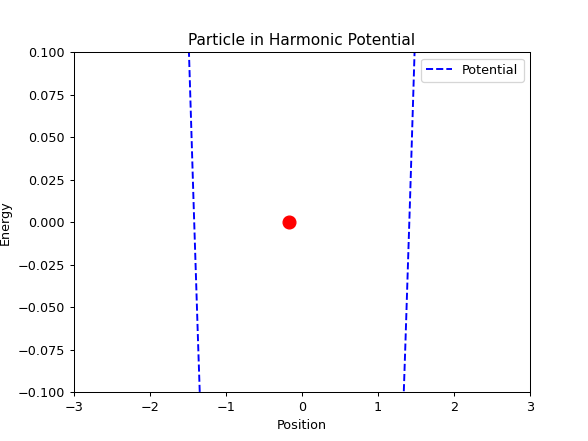

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib notebook

# Parameters
k = 1.0  # Spring constant
m = 1.0  # Mass
x0 = 2.0 # Initial position
v0 = 0.0 # Initial velocity
t = np.linspace(0, 20, 500)
omega = np.sqrt(k / m)

# Position as function of time (harmonic oscillator)
x = x0 * np.cos(omega * t) + (v0 / omega) * np.sin(omega * t)

# Set up the figure
fig, ax = plt.subplots()
ax.set_xlim(-3, 3)
ax.set_ylim(-0.1, 0.1)
particle, = ax.plot([], [], 'ro', markersize=10)  # Particle marker

# Potential well plot (static)
x_pot = np.linspace(-3, 3, 100)
ax.plot(x_pot, 0.5 * k * x_pot**2 - 1, 'b--', label='Potential')  # Shifted for visibility

# Animation function
def animate(i):
    particle.set_data([x[i]], [0])
    return particle,

ani = FuncAnimation(fig, animate, frames=len(t), interval=20, blit=True)

plt.title('Particle in Harmonic Potential')
plt.xlabel('Position')
plt.ylabel('Energy')
plt.legend()
plt.show()

## Special Projects

1. RSVP Simulator: Cosmic Structure Formation
Project Context: The RSVP Simulator models a non-expanding universe where redshift and gravity arise from entropic redistribution within a scalar-vector plenum, using a 64x64 grid to compute scalar potential (Φ), vector flow (𝒗), and entropy density (S) fields, governed by equations like ∂S/∂t = ∇²S + α(v · ∇S). This animation visualizes the evolution of entropy density and vector flow, illustrating dynamic Voronoi-Delaunay tessellation and gradient-driven anisotropic smoothing.

<IPython.core.display.Javascript object>


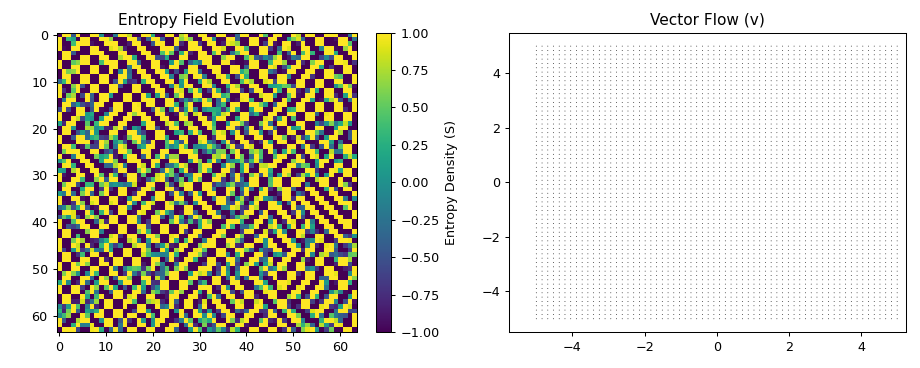

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.ndimage import gaussian_filter

%matplotlib notebook

# Simulation parameters
nx, ny = 64, 64  # Grid size
alpha = 0.1  # Coupling constant
dt = 0.01  # Time step
n_frames = 200

# Initialize fields
x, y = np.meshgrid(np.linspace(-5, 5, nx), np.linspace(-5, 5, ny))
S = np.random.normal(0, 0.1, (nx, ny))  # Entropy density
vx = np.zeros((nx, ny))  # Vector flow x-component
vy = np.zeros((nx, ny))  # Vector flow y-component

# Set up figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
im = ax1.imshow(S, cmap='viridis', vmin=-1, vmax=1)
quiver = ax2.quiver(x, y, vx, vy, scale=20)
fig.colorbar(im, ax=ax1, label='Entropy Density (S)')
ax1.set_title('Entropy Field Evolution')
ax2.set_title('Vector Flow (v)')

# Update function for animation
def update(frame):
    global S, vx, vy
    # Compute gradients
    grad_Sx, grad_Sy = np.gradient(S)
    # Update entropy field: ∂S/∂t = ∇²S + α(v · ∇S)
    laplacian_S = gaussian_filter(S, sigma=1, order=2)  # Approximate Laplacian
    v_dot_grad_S = alpha * (vx * grad_Sx + vy * grad_Sy)
    S += dt * (laplacian_S + v_dot_grad_S)
    # Update vector flow (simplified divergence-free condition)
    vx += dt * np.random.normal(0, 0.01, (nx, ny))
    vy += dt * np.random.normal(0, 0.01, (nx, ny))
    # Update plots
    im.set_array(S)
    quiver.set_UVC(vx, vy)
    return [im, quiver]

ani = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=False)
plt.tight_layout()
plt.show()

2. Crystal Plenum Theory (CPT) Experimentation Suite: Quantum Dot Lattice
Project Context: The CPT Experimentation Suite tests the crystalline lattice structure of lamphrons and lamphrodynes, using laboratory analogues like quantum dots in gallium arsenide heterostructures to measure electron density at Delaunay vertices. This animation simulates electron density fluctuations in a lattice.

<IPython.core.display.Javascript object>


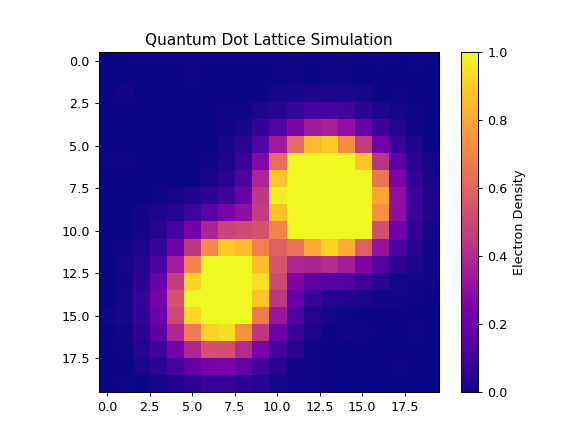

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib notebook

# Lattice parameters
nx, ny = 20, 20  # Lattice size
sigma = 1.0  # Gaussian spread for electron density
n_frames = 100

# Initialize lattice and electron density
x, y = np.meshgrid(np.linspace(-5, 5, nx), np.linspace(-5, 5, ny))
rho = np.zeros((nx, ny))  # Electron density
centers = np.random.uniform(-3, 3, (5, 2))  # Random quantum dot positions

# Set up figure
fig, ax = plt.subplots()
im = ax.imshow(rho, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(im, label='Electron Density')
ax.set_title('Quantum Dot Lattice Simulation')

# Update function
def update(frame):
    global rho
    # Simulate fluctuating electron density around quantum dots
    rho = np.zeros((nx, ny))
    for cx, cy in centers:
        rho += np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * sigma**2))
    # Add dynamic fluctuation
    rho += 0.1 * np.sin(frame / 10) * np.random.normal(0, 0.1, (nx, ny))
    rho = np.clip(rho, 0, 1)
    im.set_array(rho)
    return [im]

ani = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=True)
plt.show()

3. RSVP Phase Vortex Tracking Toolbox (PVTT): Phase Vortex Dynamics
Project Context: The PVTT detects phase vortices in neural or cosmological data, using Fourier-Space Vorticity Kernels to analyze phase transitions. This animation visualizes phase vortices in a 2D field, relevant to cosmological and neural applications.

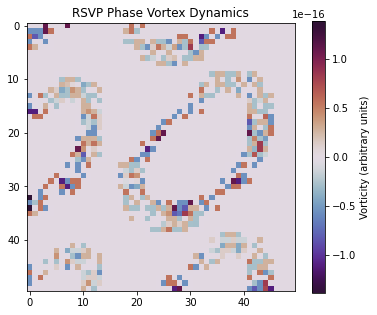

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.ndimage import gaussian_filter
from IPython.display import HTML

%matplotlib inline

nx, ny = 50, 50
x, y = np.meshgrid(np.linspace(-5, 5, nx), np.linspace(-5, 5, ny))
phase = 3 * np.sin(x) + 3 * np.cos(y) + np.sin(x + y)
n_frames = 20
interval = 500

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(phase, cmap='twilight_shifted')  # No vmin/vmax yet
plt.colorbar(im, label='Vorticity (arbitrary units)')
ax.set_title('RSVP Phase Vortex Dynamics')

def update(frame):
    global phase
    phase += 0.1 * (
        np.sin(x + y + frame / 20)
        + 0.5 * np.cos(0.5 * x - frame / 15)
        + 0.3 * np.sin(2 * y + frame / 10)
    )
    grad_x, grad_y = np.gradient(phase)
    vorticity = np.gradient(grad_y, axis=0) - np.gradient(grad_x, axis=1)
    vorticity = gaussian_filter(vorticity, sigma=0.2)
    
    vmax = np.max(np.abs(vorticity))
    im.set_clim(-vmax, vmax)  # Dynamic range for visible variation
    im.set_array(vorticity)
    return [im]

ani = FuncAnimation(fig, update, frames=n_frames, interval=interval, blit=True)
HTML(ani.to_jshtml())

4. Geozotic Power Systems: Geothermal Energy Flow
Project Context: Geozotic Power Systems explore sustainable energy generation using RSVP’s entropic principles, with experimental setups like geothermal heat pumps. This animation visualizes heat flow in a geothermal system.

<IPython.core.display.Javascript object>


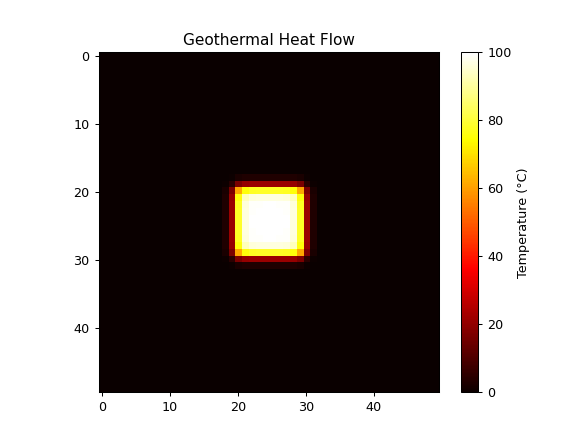

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib notebook

# Parameters
nx, ny = 50, 50
kappa = 0.1  # Thermal diffusivity
dt = 0.01
n_frames = 100

# Initialize temperature field
x, y = np.meshgrid(np.linspace(0, 10, nx), np.linspace(0, 10, ny))
T = np.zeros((nx, ny))
T[ny//2-5:ny//2+5, nx//2-5:nx//2+5] = 100  # Heat source

# Set up figure
fig, ax = plt.subplots()
im = ax.imshow(T, cmap='hot', vmin=0, vmax=100)
plt.colorbar(im, label='Temperature (°C)')
ax.set_title('Geothermal Heat Flow')

# Update function
def update(frame):
    global T
    # Heat equation: ∂T/∂t = κ ∇²T
    laplacian_T = (np.roll(T, 1, axis=0) + np.roll(T, -1, axis=0) +
                   np.roll(T, 1, axis=1) + np.roll(T, -1, axis=1) - 4*T)
    T += dt * kappa * laplacian_T
    T = np.clip(T, 0, 100)
    im.set_array(T)
    return [im]

ani = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=True)
plt.show()

5. Cyclex Climate Stabilization Architecture: Atmospheric Convection
Project Context: Cyclex Climate Stabilization Architecture uses RSVP’s entropic smoothing to design climate interventions, such as atmospheric energy redistribution. This animation visualizes a simplified convection current in the atmosphere.

<IPython.core.display.Javascript object>


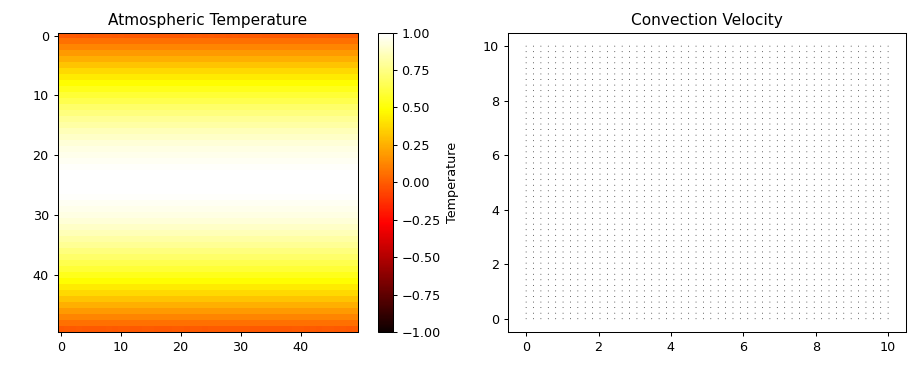

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib notebook

# Parameters
nx, ny = 50, 50
dt = 0.01
n_frames = 100

# Initialize velocity and temperature fields
x, y = np.meshgrid(np.linspace(0, 10, nx), np.linspace(0, 10, ny))
T = np.sin(np.pi * y / 10)  # Initial temperature gradient
vx = np.zeros((nx, ny))
vy = np.zeros((nx, ny))

# Set up figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
im = ax1.imshow(T, cmap='hot', vmin=-1, vmax=1)
quiver = ax2.quiver(x, y, vx, vy, scale=20)
fig.colorbar(im, ax=ax1, label='Temperature')
ax1.set_title('Atmospheric Temperature')
ax2.set_title('Convection Velocity')

# Update function
def update(frame):
    global T, vx, vy
    # Simplified convection: vy driven by temperature gradient
    grad_Tx, grad_Ty = np.gradient(T)
    vy += dt * grad_Ty  # Buoyancy-driven velocity
    vx += dt * np.random.normal(0, 0.01, (nx, ny))  # Random perturbations
    # Update temperature (advection)
    T += dt * (vx * grad_Tx + vy * grad_Ty)
    im.set_array(T)
    quiver.set_UVC(vx, vy)
    return [im, quiver]

ani = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=False)
plt.tight_layout()
plt.show()